In [2]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from ROPE import ROPE, apply_rotary_pos_emb

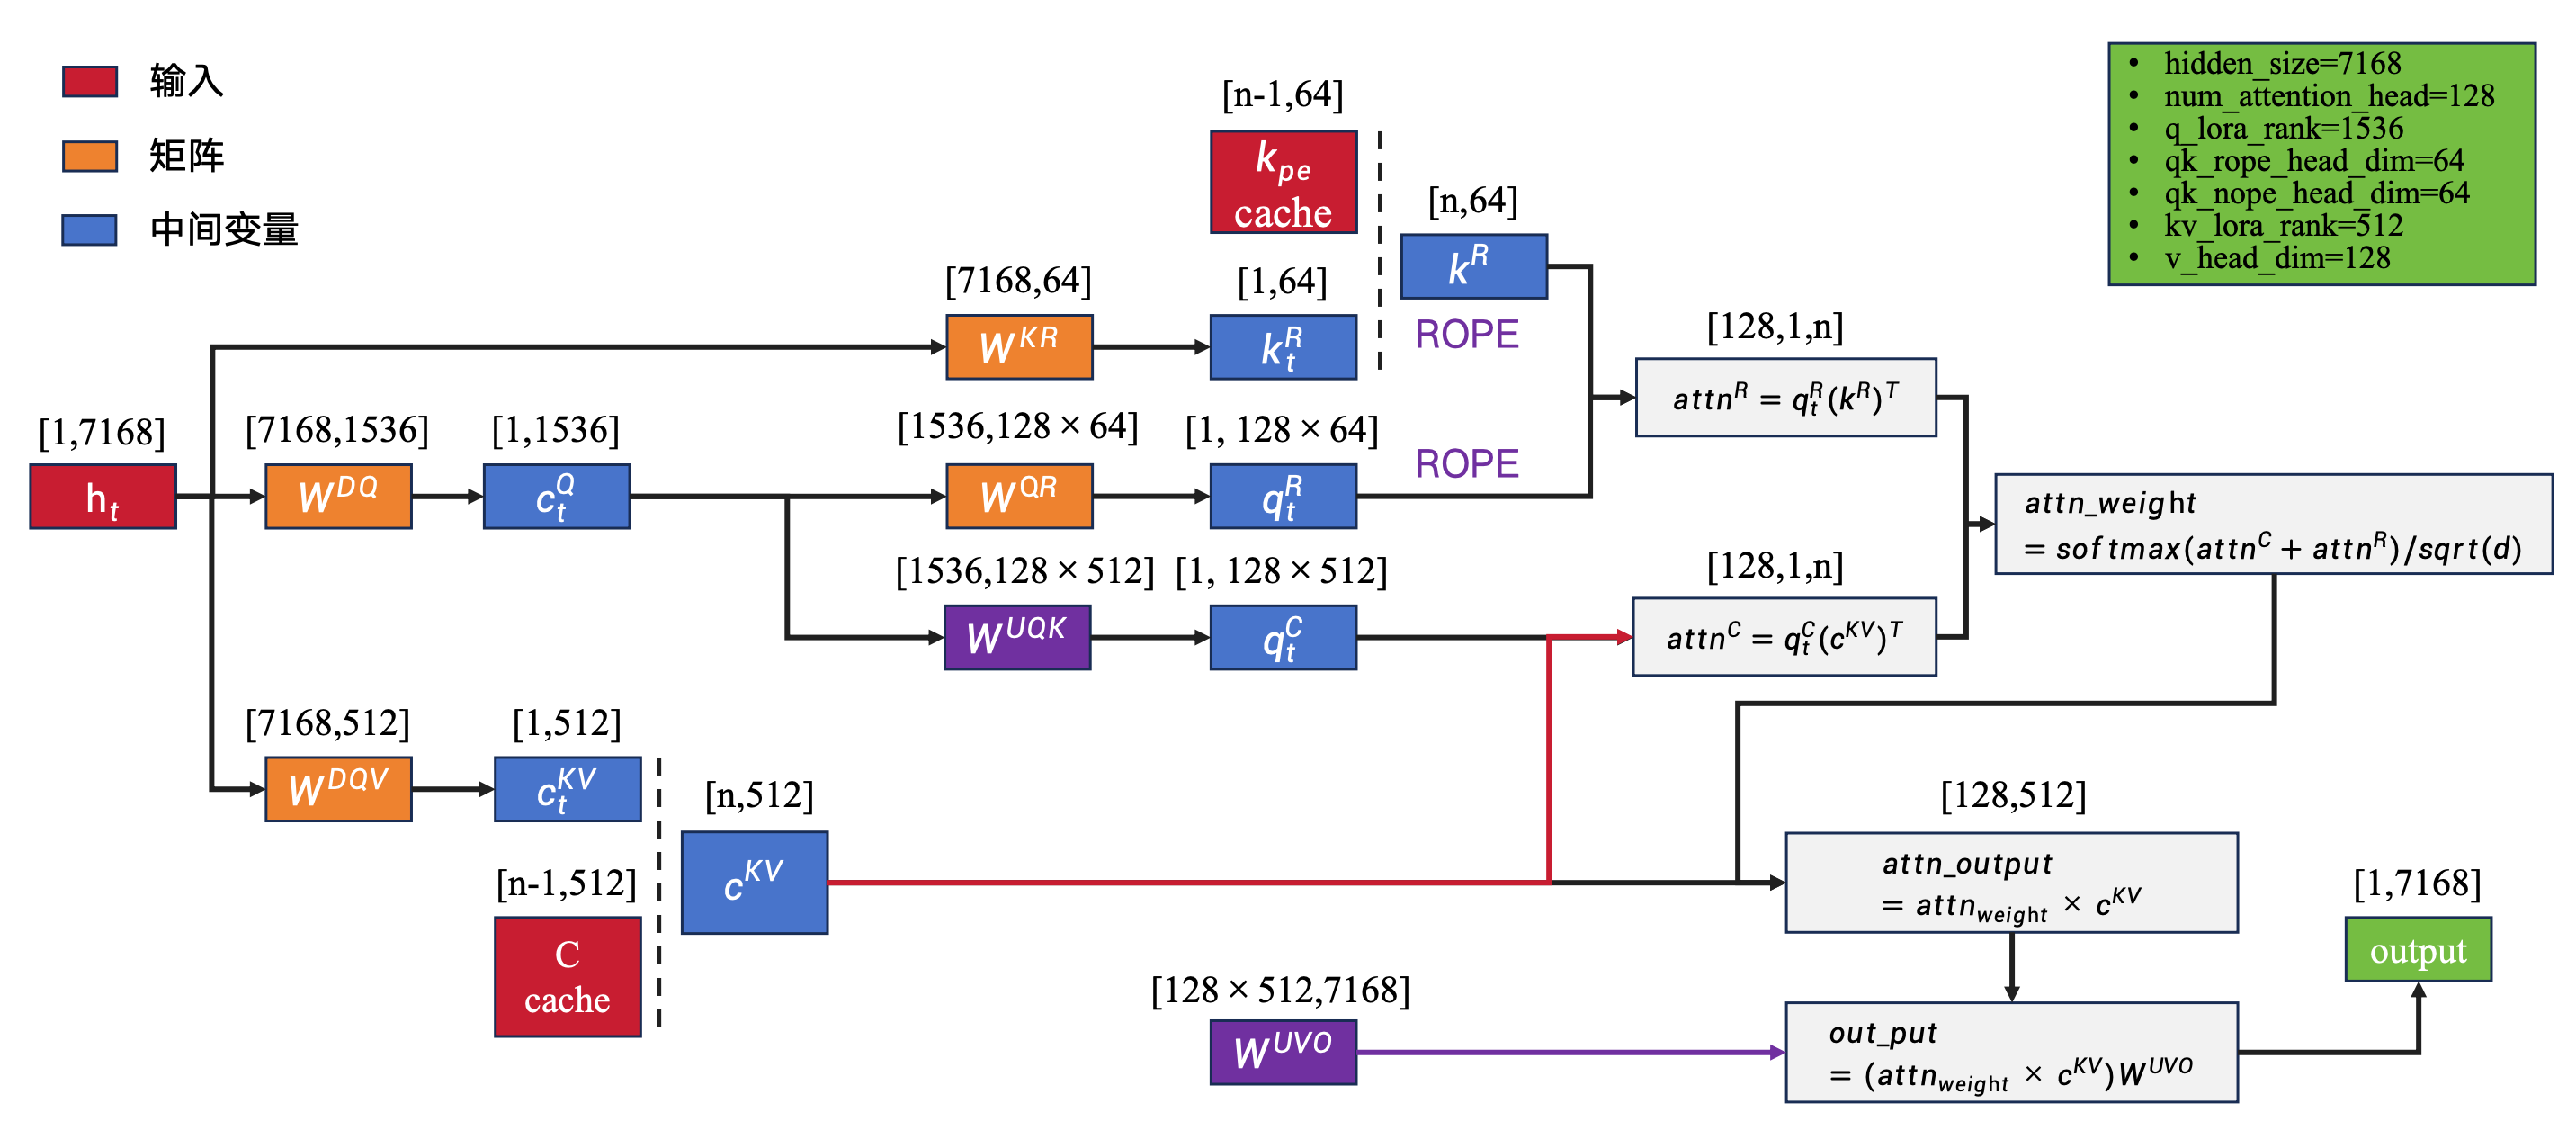

In [3]:
from IPython.display import Image, display

# 替换为你的桌面路径（关键！）
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/MLA-Decoding-Merge.png'  # ← 修改这里！

display(Image(filename=image_path))

# 手写 MLA_Decoding 阶段：提前吸收版

In [4]:
@dataclass
class Config:
    hidden_size: int
    n_heads: int
    max_pos: int
    rope_theta: float
    rope_head_dim: int
    q_lora_rank: int
    kv_lora_rank: int
    head_dim: int
    dropout: float

In [7]:
class MLADecoding(nn.Module):
    """MLA Decoding 阶段的核心实现 (提前吸收)"""

    def __init__(self, config):
        super().__init__()

        self.dropout = config.dropout
        self.hidden_size = config.hidden_size
        self.n_heads = config.n_heads
        self.max_pos = config.max_pos
        self.rope_theta = config.rope_theta

        # 对应于query压缩的向量，在deepseek v3中，hidden_size 7168
        # 压缩后的kv d_c=512, 压缩比例 1/14
        # q的压缩为1536，压缩比例为 1/4.7
        # rope的维度是 64

        # 对应 query 的压缩向量
        self.q_lora_rank = config.q_lora_rank

        # 对应query 和 key进行rope的维度
        self.rope_head_dim = config.rope_head_dim

        # 对应 key, value的压缩向量
        self.kv_lora_rank = config.kv_lora_rank

        # 对应每一个head的维度
        self.head_dim = config.head_dim

        # 对应Q， K做attention的维度，nope_dim + rope_dim
        self.q_head_dim = config.head_dim + config.rope_head_dim

        # Q的降维和升维
        self.q_down_proj = nn.Linear(
            self.hidden_size,
            self.q_lora_rank,
            bias=False
        )

        self.q_up_proj = nn.Linear(
            self.q_lora_rank,
            self.n_heads * self.head_dim,
            bias=False
        )

        self.q_pe_up_proj = nn.Linear(
            self.q_lora_rank,
            self.n_heads * self.rope_head_dim,
            bias=False
        )

        # KV的降维和升维
        self.kv_down_proj = nn.Linear(
            self.hidden_size,
            self.kv_lora_rank + self.rope_head_dim,
            bias=False
        )

        self.kv_up_proj = nn.Linear(
            self.kv_lora_rank,
            self.n_heads * (self.head_dim + self.head_dim),
            # 最终还需要做切分，一部分是K的，一部分是V的
            bias=False
        )

        # 输出映射层 O
        self.o_proj = nn.Linear(
            self.n_heads * self.head_dim,
            self.hidden_size,
            bias=False
        )

        # 初始化 ROPE 的类
        self.rotary_emb = ROPE(
            self.rope_head_dim,
            self.max_pos,
            self.rope_theta
        )

        # 获取kv up的参数
        kv_up_proj = self.kv_up_proj.weight.view(self.n_heads, self.head_dim + self.head_dim, self.kv_lora_rank)

        # UQ, UK的矩阵吸收
        # [self.n_heads, self.head_dim, self.kv_lora_rank]
        k_up = kv_up_proj[:, :self.head_dim, :]
        # [self.q_lora_rank, self.n_heads * self.head_dim]
        q_up = self.q_up_proj.weight.T.view(self.q_lora_rank, self.n_heads, self.head_dim)
        # [self.n_heads, self.q_lora_rank, self.kv_lora_rank]
        self.w_uqk = torch.einsum("qnd,ndc->qnc", q_up, k_up).transpose(0, 1)

        # UV 和 O 矩阵吸收
        # [self.n_heads, self.kv_lora_rank, self.head_dim]
        v_up = kv_up_proj[:, self.head_dim:, :].transpose(1, 2)
        o = self.o_proj.weight.T.reshape([self.n_heads, self.head_dim, self.hidden_size])
        self.w_uvo = torch.matmul(v_up, o).reshape([-1, self.hidden_size])


    def forward(
        self,
        hidden_states,
        attention_mask = None,
        position_ids = None,
        compressed_kv = None
    ):
        """
        MLA 矩阵提前吸收版本的核心实现
        """
        bsz, q_len, _ = hidden_states.size() # q_len=1

        # 1. Q的降维升维映射，以及NOPE和ROPE切分
        # q_down shape: [batch, q_len, q_lora_rank]
        # self.w_uqk shape: [self.n_heads, self.q_lora_rank, self.kv_lora_rank]
        q_down = self.q_down_proj(hidden_states)
        # q_nope shape: [batch, self.n_heads, q_len, self.kv_lora_rank]
        q_nope = torch.einsum("blc,hcd->blhd", q_down, self.w_uqk).transpose(1, 2)
        q_pe = self.q_pe_up_proj(q_down)
        q_pe = q_pe.view(bsz, q_len, self.n_heads, self.rope_head_dim).transpose(1, 2)


        # 2.KV的降维升维映射，以及NOPE和ROPE切分
        # [batch, kv_seq_len+1, self.kv_lora_rank + self.rope_head_dim]
        compressed_kv_new = self.kv_down_proj(hidden_states)
        compressed_kv = torch.concat([compressed_kv, compressed_kv_new], dim=1)
        kv_seq_len = compressed_kv.size(1)
        compressed_kv, k_pe = torch.split(
            compressed_kv, [self.kv_lora_rank, self.rope_head_dim], dim=-1
        )

        # 为了做 MQA, 升一个num_head的维度
        k_pe = k_pe.view(bsz, kv_seq_len, 1, self.rope_head_dim).transpose(1, 2)

        # 3. 给 q_pe Apply ROPE
        cos, sin = self.rotary_emb(q_pe)
        q_pe = apply_rotary_pos_emb(q_pe, cos, sin, position_ids)
        print("q pe shape: ", q_pe.shape)
        print("k pe shape: ", k_pe.shape)
        print("q_nope shape: ", q_nope.shape)

        # 4. 组合 query和 key ROPE 的部分和 NOPE 的部分
        q_merge = torch.concat([q_pe, q_nope], dim=-1)
        k_merge = torch.concat([k_pe, compressed_kv.unsqueeze(-3)], dim=-1)

        # 5. 计算注意力得分
        attn_weights = torch.matmul(q_merge, k_merge.transpose(2, 3))
        attn_weights = attn_weights / math.sqrt(self.q_head_dim)

        # 6. 计算Softmax 和 dropout
        attn_weights = F.softmax(
            attn_weights, dim=-1, dtype=torch.float32
        ).to(q_nope.dtype)
        attn_weights = F.dropout(attn_weights, p=self.dropout, training=self.training)

        # 7. 计算注意力输出
        # attn_weights shape=[batch, self.n_heads, q_len, kv_seq_len]
        # compressed_kv shape=[batch, kv_seq_len, k_lora_rank]
        attn_output = torch.einsum("bnql,blc->bnqc", attn_weights, compressed_kv)
        # attn_output shape = [batch, self.n_heads, q_len, k_lora_rank]
        # self.w_uvo shape = [self.n_heads*self.kv_lora_rank, self.hidden_size]
        attn_output_t = attn_output.transpose(1, 2).reshape(bsz, q_len, -1) # [batch, q_len, self.n_heads*k_lora_rank]
        attn_output = torch.matmul(attn_output_t, self.w_uvo)


        return attn_output, attn_weights

In [8]:
import numpy as np
torch.random.manual_seed(42)

config = Config(
    hidden_size=7168,
    n_heads=128,
    max_pos=1024,
    rope_theta=50000,
    rope_head_dim=64,
    q_lora_rank=1536,
    kv_lora_rank=512,
    head_dim=128,
    dropout=0.1
)
print(config)

# 定义参数
batch_size = 2
q_len = 1
kv_seq_len = 10

# 生成测试数据
q = torch.randn(batch_size, q_len, config.hidden_size)

# 构造position_ids, 这里注意和prefill的区别，输入只有最新的一个Q，即只有一个token
position_ids = torch.full((batch_size, q_len), kv_seq_len, dtype=torch.long)
print(position_ids)

# 构造compressed_kv，加载prefill阶段的c_KV, K_R
compressed_kv = torch.FloatTensor((np.load("mla_cache.npy")))
print("compressed_kv shape: ", compressed_kv.shape)

# 初始化模型
model = MLADecoding(config)

# 解码
attn_output, attn_weights = model(q, None, position_ids, compressed_kv)
print("attn_weights shape: ", attn_weights.shape)
print("attn_output shape: ", attn_output.shape)
print("attn_output: ", attn_output)

Config(hidden_size=7168, n_heads=128, max_pos=1024, rope_theta=50000, rope_head_dim=64, q_lora_rank=1536, kv_lora_rank=512, head_dim=128, dropout=0.1)
tensor([[10],
        [10]])
compressed_kv shape:  torch.Size([2, 10, 576])
q pe shape:  torch.Size([2, 128, 1, 64])
k pe shape:  torch.Size([2, 1, 11, 64])
q_nope shape:  torch.Size([2, 128, 1, 512])
attn_weights shape:  torch.Size([2, 128, 1, 11])
attn_output shape:  torch.Size([2, 1, 7168])
attn_output:  tensor([[[ 0.0777, -0.0066,  0.0218,  ...,  0.0152,  0.0414, -0.0234]],

        [[ 0.1077, -0.0270, -0.0919,  ...,  0.0841,  0.0849,  0.0843]]],
       grad_fn=<UnsafeViewBackward0>)
